In [6]:
import sys 
sys.path.append('/Users/clairewilliams/opt/anaconda3/lib/python3.9/site-packages')
sys.path.append('../model-timescales/src')
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from timescales import TimescaleEnsemble
from timescales.data import build_bulk_energy_grid
from astropy.cosmology import FlatLambdaCDM
from timescales.analysis.modelv2 import create_dynamical_model_integral

cosmo = FlatLambdaCDM(71,0.27,Ob0=0.044, Tcmb0=2.726 *u.K)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 15

In [48]:
grid_size = 10
cutoff_density=1e6*u.Msun/(u.pc**3)

masses_array   = np.logspace(4, 9, grid_size) * u.Msun
radii_array    = np.logspace(-0.7, 2, grid_size) * u.pc
velocity_array = np.logspace(-0.7, 2.2, grid_size) * u.km/u.s

grid = build_bulk_energy_grid(masses_array, radii_array, velocity_array,
                              alpha=3/5, energy_unit=u.erg, cutoff_density=cutoff_density)


In [49]:
#set parameters
alpha = 1.25
Nsampling = 10

In [50]:
#create the timescale object

model_nobh = TimescaleEnsemble(grid, 
                    densityModel="power-law",
                    Nsampling = Nsampling,
                    timescales_kwargs={'cosmology':cosmo},
                    profile_kwargs={"alpha":alpha})

Using power-law model with properties:
alpha=1.25
Using parameters for timescale evaluation
cosmology=FlatLambdaCDM(H0=71.0 km / (Mpc s), Om0=0.27, Tcmb0=2.726 K, Neff=3.04, m_nu=[0. 0. 0.] eV, Ob0=0.044)
No imf arguments given. Defaulting to 'salpeter defaults'.


In [51]:
out_nobh = create_dynamical_model_integral(model_nobh)

will use defaults for  {'Mcollisions': <Quantity 1. solMass>, 'n_unit': <Quantity 1. 1 / cm3>, 'v_unit': Unit("cm / s"), 'Mstar_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'M_obj': <Quantity 10. solMass>, 'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Using nearest neighbor for interaction type.
No Metallicity given! Using 0.1 solar
Getting disruption times for 124 systems


/Users/clairewilliams/Research/Calculations/timescale-plots/../model-timescales/src/timescales/physics/halo_environment.py:135: RuntimeWarning: invalid value encountered in divide
  normalization_offset = stfunction17/stfunction


Integrating outputs for 124 systems


/Users/clairewilliams/Research/Calculations/timescale-plots/../model-timescales/src/timescales/analysis/modelv2.py:269: RuntimeWarning: invalid value encountered in scalar power
  out['M_VMS'][sys_id]= (out['mass_accretion_rate'][sys_id].to_value(u.Msun/u.yr)/(10**(-9.13)*Z**0.74))**(1./2.1)* u.Msun


In [52]:
# BH_masses = np.logspace(2,7,11) * u.Msun
BH_masses = np.logspace(2,7,6) * u.Msun

In [58]:

models = {}
outs = {}
for i in range(len(BH_masses)):
    BHmass = BH_masses[i]
    name = "model_bh_"+str(i)
    models[name]=TimescaleEnsemble(grid, 
                        densityModel= "PowerLawBH", 
                        Nsampling = Nsampling,
                        profile_kwargs = {"alpha":alpha, 'M_bh':BH_masses[i]} )
    outs[name] = create_dynamical_model_integral(models[name])


Using PowerLawBH model with properties:
alpha=1.25
M_bh=100.0 solMass
No timescale arguments given. Defaulting to eccentricity 0, Mstar 1Msun.
No imf arguments given. Defaulting to 'salpeter defaults'.
will use defaults for  {'Mcollisions': <Quantity 1. solMass>, 'n_unit': <Quantity 1. 1 / cm3>, 'v_unit': Unit("cm / s"), 'Mstar_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'M_obj': <Quantity 10. solMass>, 'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
Selected coulomb function based on BH or not.
will use defaults for  {'v_unit': Unit("km / s"), 'rho_unit': Unit("g / cm3"), 'mass_unit': Unit("solMass")}
No cosmology provided. Initializing flat LCDM with H0 = 71,Om = 0.27, Ob0 = 0.044,Tcmb0=2.726 
Using nearest neighbor for interaction type.
No Metal

/var/folders/lb/lrz69vl55k37335cb4q3lxnw0000gn/T/ipykernel_99804/2059454165.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize = 12)


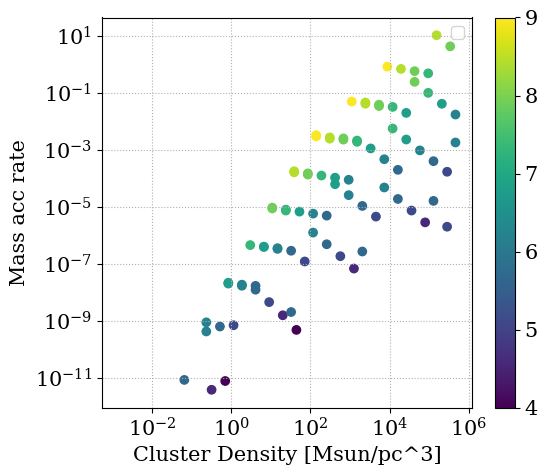

In [54]:
out = out_nobh
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(out['rho0']*(u.Msun/(u.pc**3)),out['mass_accretion_rate']*(u.Msun/u.yr),
               c=np.log10((out['mass']*u.Msun ).value))
plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r"Cluster Density [Msun/pc^3]")
ax.set_ylabel(r"Mass acc rate")
ax.legend(fontsize = 12)
ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)

plt.tight_layout()
# plt.savefig("Mdot.pdf")
plt.show()

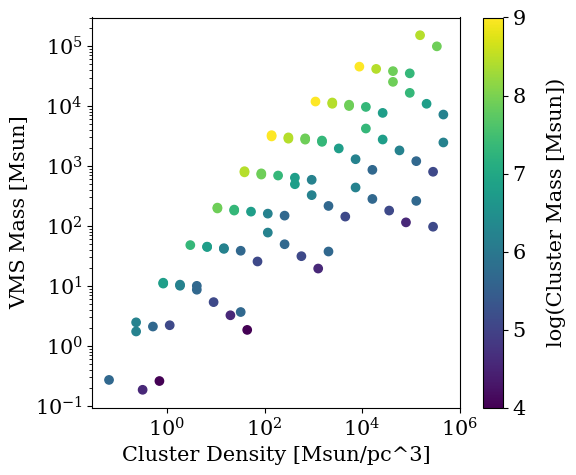

In [55]:
out = out_nobh
fig, ax = plt.subplots(figsize=(6, 5))
plt.scatter(out['rho0']*(u.Msun/(u.pc**3)),out['M_VMS']*(u.Msun),
               c=np.log10((out['mass']*u.Msun ).value))
cbar = plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r"Cluster Density [Msun/pc^3]")
ax.set_ylabel(r"VMS Mass [Msun]")
cbar.set_label(r'log(Cluster Mass [Msun])', rotation=90, labelpad=15)
# ax.legend(fontsize = 12)
# ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)

plt.tight_layout()
# plt.savefig("Mdot.pdf")
plt.show()

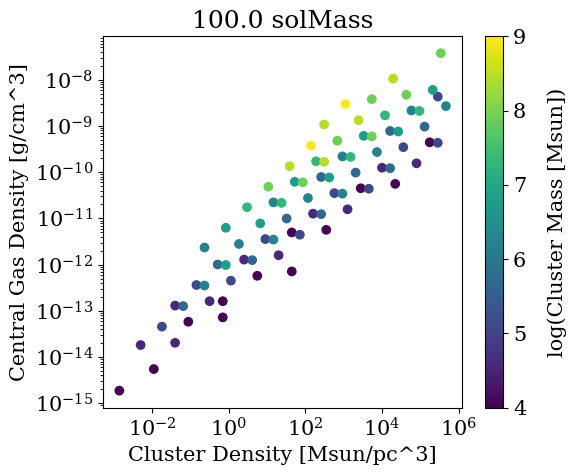

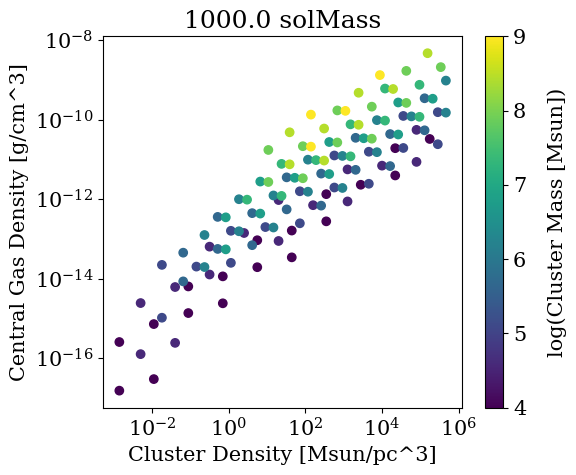

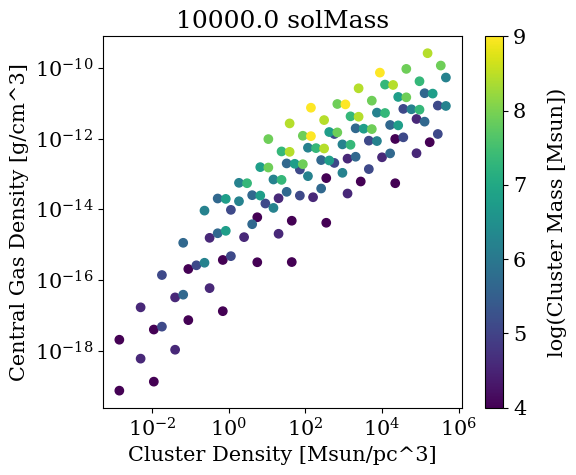

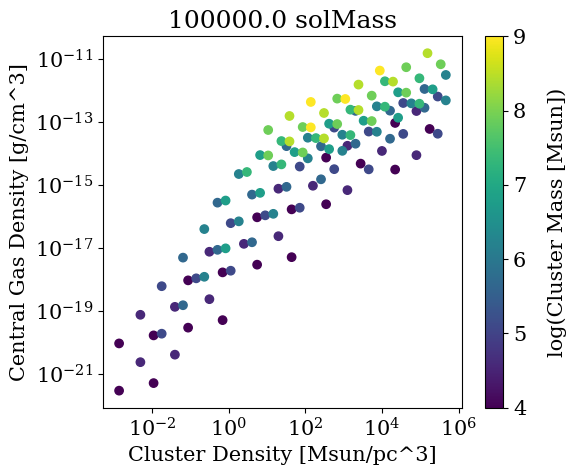

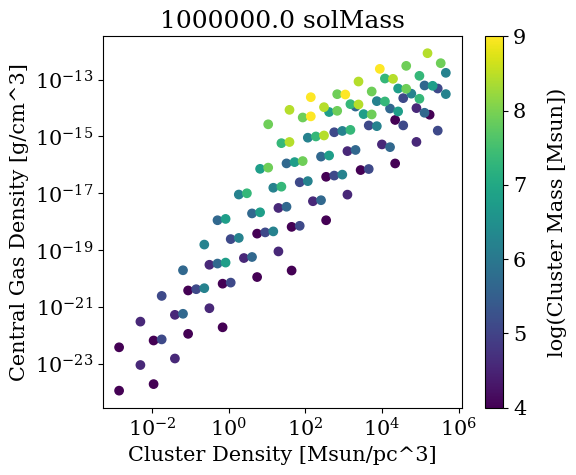

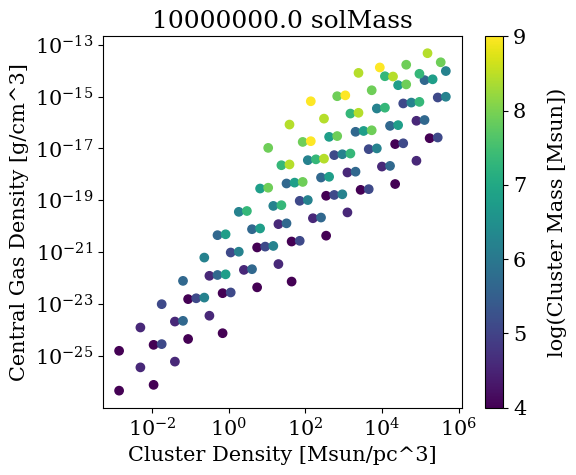

In [61]:
out = outs['model_bh_5']
for i in range(len(BH_masses)):
    BHmass = BH_masses[i]
    name = "model_bh_"+str(i)
    out = outs[name]
    fig, ax = plt.subplots(figsize=(6, 5))
    plt.scatter(out['rho0']*(u.Msun/(u.pc**3)),out['rhotot_ml']*(u.g/(u.cm**3)),
                c=np.log10((out['mass']*u.Msun ).value))
    cbar = plt.colorbar()

    #  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel(r"Cluster Density [Msun/pc^3]")
    ax.set_ylabel(r"Central Gas Density [g/cm^3]")
    cbar.set_label(r'log(Cluster Mass [Msun])', rotation=90, labelpad=15)
    # ax.legend(fontsize = 12)
    # ax.grid(True, which="both", ls=":")
    # add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)
    ax.set_title(str(BHmass))
    plt.tight_layout()
    # plt.savefig("Mdot.pdf")
    plt.show()

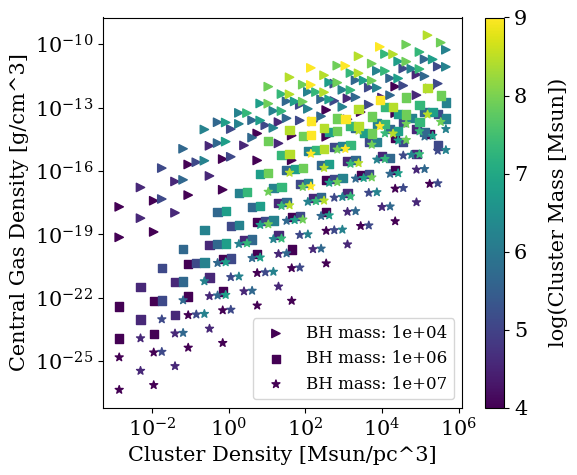

In [76]:
out = outs['model_bh_5']

fig, ax = plt.subplots(figsize=(6, 5))
markers = ['D', '^','>','<','s','*']
for i in [2,4,5]:
    BHmass = BH_masses[i].to_value("Msun")
    name = "model_bh_"+str(i)
    out = outs[name]
    plt.scatter(out['rho0']*(u.Msun/(u.pc**3)),out['rhotot_ml']*(u.g/(u.cm**3)),
                c=np.log10((out['mass']*u.Msun ).value), marker = markers[i], 
                label=f"BH mass: {BHmass:.0e}")
cbar = plt.colorbar()

#  plt.loglog(tester['mass_accretion_rate']*(u.Msun/u.yr))
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r"Cluster Density [Msun/pc^3]")
ax.set_ylabel(r"Central Gas Density [g/cm^3]")
cbar.set_label(r'log(Cluster Mass [Msun])', rotation=90, labelpad=15)
ax.legend(fontsize = 12)
# ax.grid(True, which="both", ls=":")
# add_top_mass_axis(ax, rho0=rho0, r0=r0, alpha=alpha, n_ticks=5)
# ax.set_title(str(BHmass))
plt.tight_layout()
# plt.savefig("Mdot.pdf")
plt.show()

In [ ]:
out = outs['mdel_bh_5']
